In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib as mpl
from scipy.stats import friedmanchisquare, wilcoxon
from itertools import combinations

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['font.family']  = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']

df = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/grouped+isolated/interaction_type_bout.csv')

# tracks 0-4 = SI, 5-9 = GH
def contact_type(t1, t2):
    a = 'GH' if t1 >= 5 else 'SI'
    b = 'GH' if t2 >= 5 else 'SI'
    if a == 'GH' and b == 'GH': return 'GH-GH'
    if a == 'SI' and b == 'SI': return 'SI-SI'
    return 'GH-SI'

# same pair regardless of track order: (3,7) == (7,3)
df['t_lo'] = df[['track_1', 'track_2']].min(axis=1)
df['t_hi'] = df[['track_1', 'track_2']].max(axis=1)
df['contact_type'] = df.apply(lambda r: contact_type(r['t_lo'], r['t_hi']), axis=1)

def covered_frames(intervals):
    merged = []
    for start, end in sorted(intervals):
        if merged and start <= merged[-1][1]:
            merged[-1] = (merged[-1][0], max(merged[-1][1], end))
        else:
            merged.append([start, end])
    return sum(e - s + 1 for s, e in merged)

TOTAL_SECONDS = 3600
TYPES      = ['GH-GH', 'GH-SI', 'SI-SI']          # plot order
COLORS     = {'GH-GH': '#50859f', 'GH-SI': '#8c6bb1', 'SI-SI': '#c45242'}
N_PAIRS    = {'GH-GH': 10, 'GH-SI': 25, 'SI-SI': 10}  # available pairings (45 total)
TOTAL_PAIRS = sum(N_PAIRS.values())

# contact seconds per pair per video
pair_secs = (
    df.groupby(['file', 't_lo', 't_hi', 'contact_type'])
    .apply(lambda g: covered_frames(zip(g['start_frame'], g['end_frame'])))
    .reset_index(name='contact_seconds')
)

# all 45 possible pairs x all videos, so pairs that never touched count as 0
files = df['file'].unique()
all_pairs = pd.DataFrame(
    [(f, a, b, contact_type(a, b)) for f in files for a, b in combinations(range(10), 2)],
    columns=['file', 't_lo', 't_hi', 'contact_type']
)
pair_secs = all_pairs.merge(pair_secs, on=['file', 't_lo', 't_hi', 'contact_type'], how='left')
pair_secs['contact_seconds'] = pair_secs['contact_seconds'].fillna(0)

# RAW: per video, total pair-contact time of each pairing type / 3600
per_video = (
    pair_secs.groupby(['file', 'contact_type'])['contact_seconds'].sum()
    .div(TOTAL_SECONDS).rename('proportion').reset_index()
)
per_video.head()


,file,contact_type,proportion
0,2026-02-17_11-29-18_td11.tracks.feather,GH-GH,0.103056
1,2026-02-17_11-29-18_td11.tracks.feather,GH-SI,0.213889
2,2026-02-17_11-29-18_td11.tracks.feather,SI-SI,0.090278
3,2026-02-17_11-33-08_td12.tracks.feather,GH-GH,0.098889
4,2026-02-17_11-33-08_td12.tracks.feather,GH-SI,0.071667


Friedman chi2=22.17, p=1.537e-05
  GH-GH vs GH-SI: p_bonf=0.004395
  GH-SI vs SI-SI: p_bonf=0.001465
  GH-GH vs SI-SI: p_bonf=0.001465


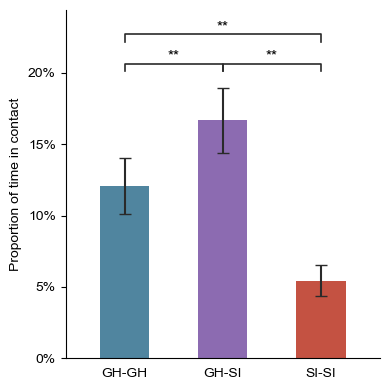

In [30]:
# --- shared helpers: stats + barplot ---
def run_stats(pv):
    stat, p = friedmanchisquare(*[pv[t] for t in TYPES])
    print(f'Friedman chi2={stat:.2f}, p={p:.4g}')
    pw = {}
    for a, b in [('GH-GH', 'GH-SI'), ('GH-SI', 'SI-SI'), ('GH-GH', 'SI-SI')]:
        _, pp = wilcoxon(pv[a], pv[b])
        pw[(a, b)] = min(pp * 3, 1.0)  # Bonferroni x3
        print(f'  {a} vs {b}: p_bonf={pw[(a, b)]:.4g}')
    return pw

def p_to_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

def barplot(pv, pw, ylabel, fname, percent=True, ref_line=None):
    fig, ax = plt.subplots(figsize=(4, 4))
    tops = []
    for i, t in enumerate(TYPES):
        v = pv[t].values
        m, ci = v.mean(), 1.96 * v.std(ddof=1) / np.sqrt(len(v))
        tops.append(m + ci)
        ax.bar(i, m, width=0.5, color=COLORS[t], zorder=2)
        ax.errorbar(i, m, yerr=ci, color='#2a2a2a', capsize=4, linewidth=1.5, zorder=3)
    if ref_line is not None:
        ax.axhline(ref_line, color='#2a2a2a', linewidth=1, linestyle='--', zorder=1)
    top  = max(tops + ([ref_line] if ref_line else []))
    step = top * 0.09
    for (x1, x2, pair, y) in [(0, 1, ('GH-GH', 'GH-SI'), top + step),
                              (1, 2, ('GH-SI', 'SI-SI'), top + step),
                              (0, 2, ('GH-GH', 'SI-SI'), top + 2.2 * step)]:
        ax.plot([x1, x1, x2, x2], [y - step * 0.3, y, y, y - step * 0.3], color='#2a2a2a', linewidth=1.2)
        lab = p_to_stars(pw[pair])
        ax.text((x1 + x2) / 2, y, lab, ha='center', va='bottom', fontsize=11 if lab != 'ns' else 9)
    ax.set_xticks(range(3)); ax.set_xticklabels(TYPES)
    ax.set_ylabel(ylabel)
    ax.set_xlim(-0.6, 2.6); ax.set_ylim(0, top + 3.2 * step)
    if percent:
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(bottom=False)
    plt.tight_layout()
    import os
    os.makedirs(r'/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/FIGURE-2/group+iso(mixed)', exist_ok=True)
    plt.savefig(os.path.join(r'/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/FIGURE-2/group+iso(mixed)', fname), bbox_inches='tight')
    plt.show()

# --- 1. RAW barplot: proportion of time in contact per pairing type ---
pv_raw = per_video.pivot(index='file', columns='contact_type', values='proportion')
pw_raw = run_stats(pv_raw)
barplot(pv_raw, pw_raw, 'Proportion of time in contact', 'proportion_contact_type_raw.pdf')


In [31]:
# --- 2. NORMALISE by available pairings ---
# 10 GH-GH, 25 GH-SI, 10 SI-SI possible pairs (45 total).
# normalised = (share of all contact that is this type) / (share of pairs that are this type)
#            = observed / expected under random mixing
# 1 = what you'd get if larvae contacted everyone at random; >1 = preferred; <1 = avoided
tot = per_video.groupby('file')['proportion'].transform('sum')
per_video['share']      = per_video['proportion'] / tot
per_video['expected']   = per_video['contact_type'].map(N_PAIRS) / TOTAL_PAIRS
per_video['normalised'] = per_video['share'] / per_video['expected']

print(per_video.groupby('contact_type')[['share', 'expected', 'normalised']].mean().round(3))


              share  expected  normalised
contact_type                             
GH-GH         0.356     0.222       1.602
GH-SI         0.485     0.556       0.872
SI-SI         0.159     0.222       0.717


Friedman chi2=18.67, p=8.843e-05
  GH-GH vs GH-SI: p_bonf=0.001465
  GH-SI vs SI-SI: p_bonf=0.06299
  GH-GH vs SI-SI: p_bonf=0.001465


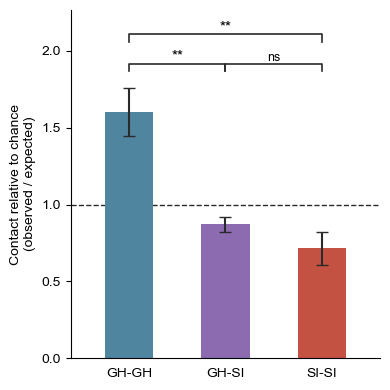

In [32]:
# --- 3. NORMALISED barplot ---
pv_norm = per_video.pivot(index='file', columns='contact_type', values='normalised')
pw_norm = run_stats(pv_norm)
barplot(pv_norm, pw_norm, 'Contact relative to chance\n(observed / expected)',
        'proportion_contact_type_normalised.pdf', percent=False, ref_line=1)


In [33]:
# --- 4. OVER TIME: same two metrics in 600 s bins ---
BIN_SIZE = 600
bins = list(range(0, TOTAL_SECONDS, BIN_SIZE))
df['time_bin'] = (df['start_frame'] // BIN_SIZE) * BIN_SIZE

bin_secs = (
    df.groupby(['file', 't_lo', 't_hi', 'contact_type', 'time_bin'])
    .apply(lambda g: covered_frames(zip(g['start_frame'], g['end_frame'])))
    .reset_index(name='contact_seconds')
)
all_pairs_bins = pd.concat([all_pairs.assign(time_bin=b) for b in bins], ignore_index=True)
bin_secs = all_pairs_bins.merge(bin_secs, on=['file', 't_lo', 't_hi', 'contact_type', 'time_bin'], how='left')
bin_secs['contact_seconds'] = bin_secs['contact_seconds'].fillna(0)

per_video_binned = (
    bin_secs.groupby(['file', 'contact_type', 'time_bin'])['contact_seconds'].sum()
    .div(BIN_SIZE).rename('proportion').reset_index()
)
tot_b = per_video_binned.groupby(['file', 'time_bin'])['proportion'].transform('sum')
per_video_binned['normalised'] = (per_video_binned['proportion'] / tot_b) / \
    (per_video_binned['contact_type'].map(N_PAIRS) / TOTAL_PAIRS)
# a video with no contact at all in a bin has no share -> leave it out of the normalised mean
per_video_binned.head()


,file,contact_type,time_bin,proportion,normalised
0,2026-02-17_11-29-18_td11.tracks.feather,GH-GH,0,0.135000,1.506198
1,2026-02-17_11-29-18_td11.tracks.feather,GH-GH,600,0.068333,0.823661
2,2026-02-17_11-29-18_td11.tracks.feather,GH-GH,1200,0.063333,0.818182
3,2026-02-17_11-29-18_td11.tracks.feather,GH-GH,1800,0.213333,2.071942
4,2026-02-17_11-29-18_td11.tracks.feather,GH-GH,2400,0.086667,0.724458


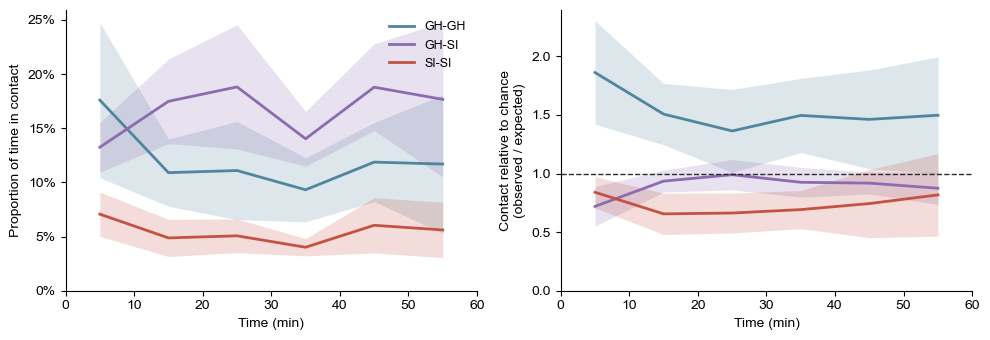

In [34]:
# --- 5. Lineplots: raw (left) and normalised (right), 95% CI ---
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, col, ylabel in [(axes[0], 'proportion', 'Proportion of time in contact'),
                        (axes[1], 'normalised', 'Contact relative to chance\n(observed / expected)')]:
    for t in TYPES:
        g  = per_video_binned[per_video_binned['contact_type'] == t].groupby('time_bin')[col]
        m  = g.mean()
        ci = 1.96 * g.std(ddof=1) / np.sqrt(g.count())
        x  = (m.index + BIN_SIZE / 2) / 60
        ax.plot(x, m.values, color=COLORS[t], linewidth=2, label=t)
        ax.fill_between(x, (m - ci).values, (m + ci).values, color=COLORS[t], alpha=0.2, linewidth=0)
    ax.set_xlabel('Time (min)'); ax.set_ylabel(ylabel)
    ax.set_xlim(0, 60); ax.set_ylim(0)
    ax.spines[['top', 'right']].set_visible(False)
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
axes[1].axhline(1, color='#2a2a2a', linewidth=1, linestyle='--')
axes[0].legend(frameon=False, fontsize=9)
plt.tight_layout()
import os
os.makedirs(r'/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/FIGURE-2/group+iso(mixed)', exist_ok=True)
plt.savefig(os.path.join(r'/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/FIGURE-2/group+iso(mixed)', 'proportion_contact_type_overtime.pdf'), bbox_inches='tight')
plt.show()
